  OTDR ANALYSIS — Wavelength: 1310 nm
  Date: 2026-05-28 at 17:35 (GMT+1:00)

  CH1 (Fiber0129.sor)
    Span length:            737.6 m
    Total span loss:        4.145 dB   (η = 0.385)
    ├─ Fiber attenuation:   0.572 dB
    └─ Connector losses:    3.573 dB  (3 events)
         Event 2 @ 10 m:  2.615 dB  (cumul: 2.631 dB)
         Event 3 @ 307 m:  0.283 dB  (cumul: 2.989 dB)
         Event 4 @ 378 m:  0.675 dB  (cumul: 3.784 dB)
    Expected fiber (0.35 dB/km × 738 m): 0.258 dB

  CH2 (Fiber0130.sor)
    Span length:            739.8 m
    Total span loss:        2.982 dB   (η = 0.503)
    ├─ Fiber attenuation:   0.275 dB
    └─ Connector losses:    2.707 dB  (5 events)
         Event 2 @ 14 m:  0.446 dB  (cumul: 0.469 dB)
         Event 3 @ 306 m:  0.378 dB  (cumul: 0.921 dB)
         Event 4 @ 371 m:  0.697 dB  (cumul: 1.635 dB)
         Event 5 @ 432 m:  0.284 dB  (cumul: 1.934 dB)
         Event 6 @ 734 m:  0.902 dB  (cumul: 2.980 dB)
    Expected fiber (0.35 dB/km × 740 m): 0.

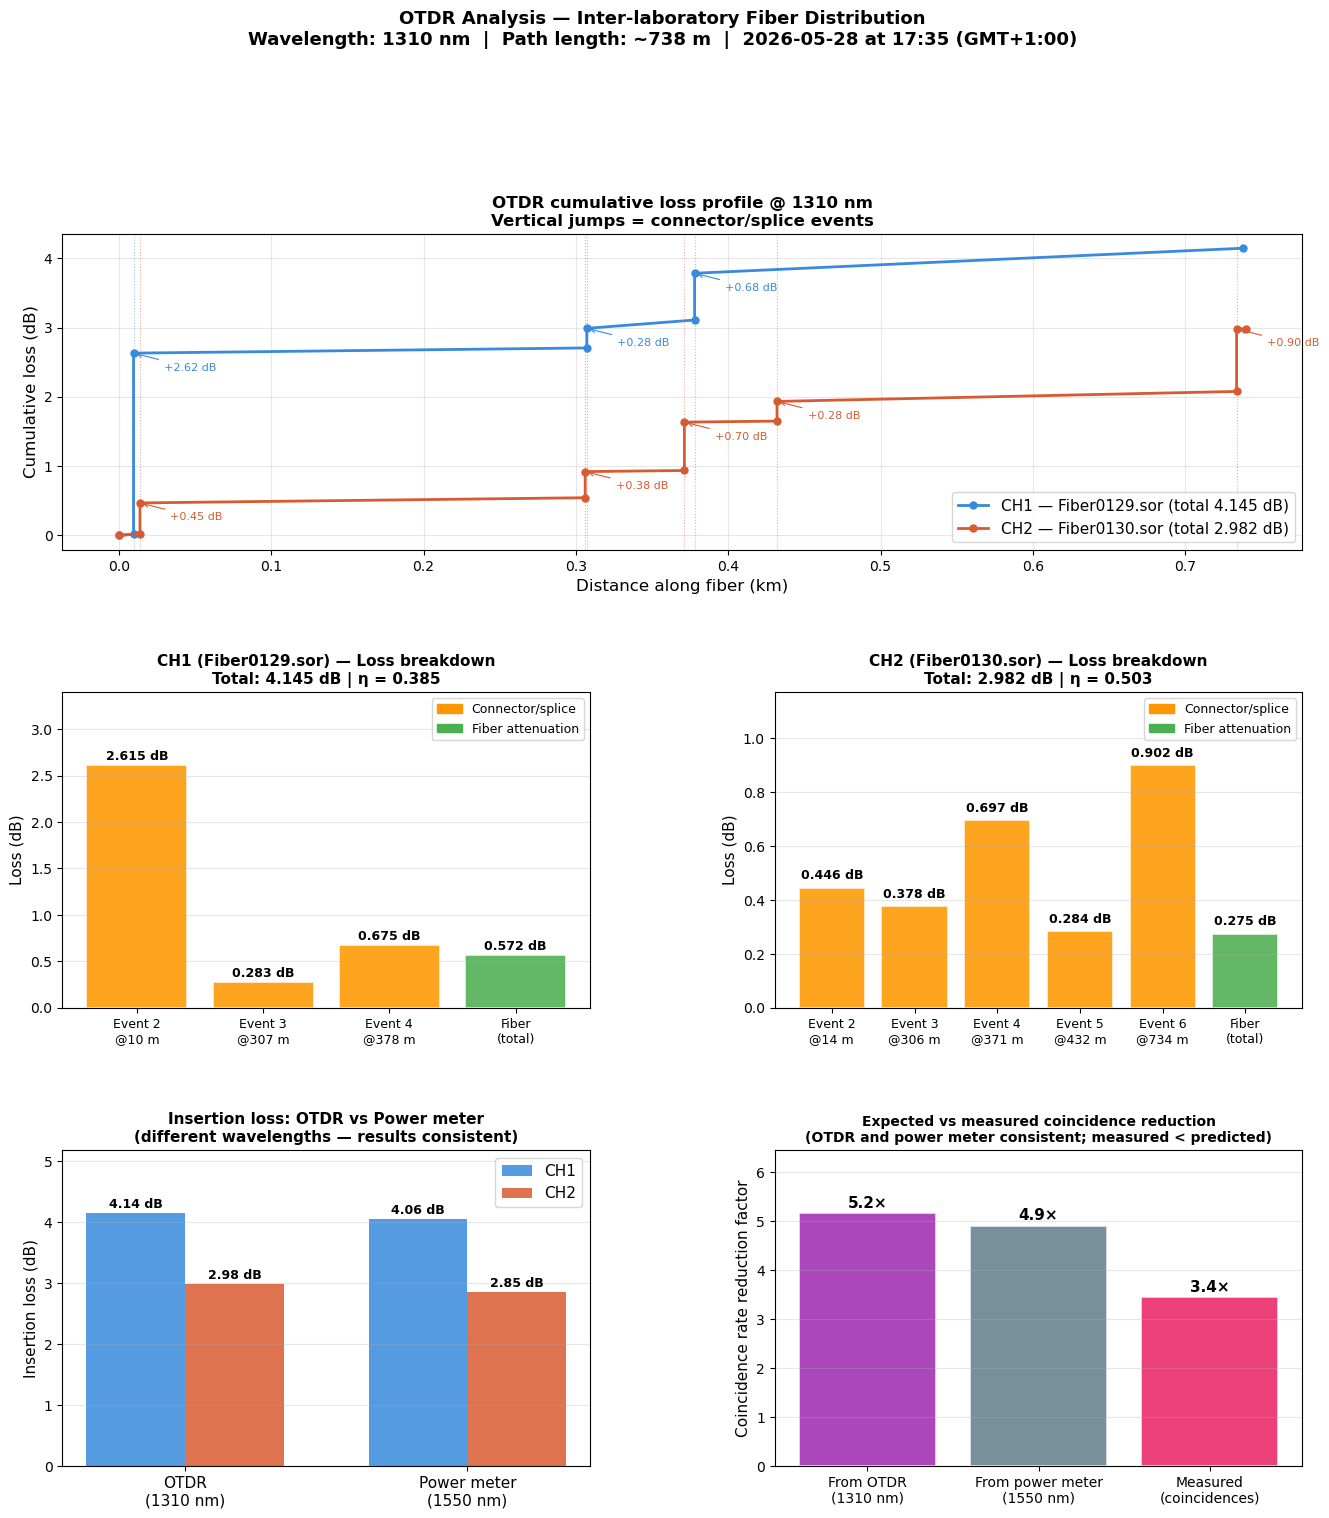

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import xml.etree.ElementTree as ET
import os

# ============================================================
# OTDR ANALYSIS — reads directly from EXFO XML files
# Power meter measurements hardcoded (from lab notebook)
# ============================================================

# ---- CONFIGURATION ----
DATA_DIR     = r"."   # <- folder containing EPPS1.xml and EPPS2.xml
XML_FILES    = {'CH1': 'EPPS1.xml', 'CH2': 'EPPS2.xml'}

# Power meter measurements (1550 nm reference laser, 1 m reference fiber)
P_REF_mW  = 3.18   # reference: laser -> 1 m fiber -> detector
P_CH1_mW  = 1.25   # channel 1: full distribution path
P_CH2_mW  = 1.65   # channel 2: full distribution path

# ---- 1. PARSE XML FILES ----
def parse_otdr_xml(filepath):
    """Parse an EXFO OTDR XML report and return a structured dictionary."""
    tree = ET.parse(filepath)
    root = tree.getroot()
    trace = root.find('.//Trace')

    # Header info
    wavelength  = trace.find('TitleLabel').text.strip()
    filename    = trace.find('.//FileName').text.strip()
    date        = trace.find('.//Date').text.strip()

    # Link measurements
    lm = trace.find('LinkMeasurement')
    span_loss   = float(lm.find('SpanLoss').text.replace(' dB', '').strip())
    span_length = float(lm.find('SpanLength').text.replace(' m', '').strip())
    avg_loss    = lm.find('AverageLoss').text.strip()

    # Events table
    segments = []
    for ev in trace.findall('.//Event'):
        num  = ev.find('Number').text.strip()
        loc  = ev.find('Location').text.strip()
        typ  = ev.find('Type').text.strip()
        loss_raw = ev.find('Loss').text.strip()
        att_raw  = ev.find('Attenuation').text.strip() if ev.find('Attenuation') is not None else ''
        cum_raw  = ev.find('Cumulative').text.strip()

        # Skip header/end events with no loss value
        loss_val = None
        if loss_raw not in ('&nbsp;', '- -', ''):
            try:
                loss_val = float(loss_raw)
            except ValueError:
                pass

        cum_val = float(cum_raw) if cum_raw not in ('&nbsp;', '') else None

        # Parse location: either '0.0097' (connector) or '(0.0097 km)' (fiber section)
        if loc.startswith('(') and 'km' in loc:
            loc_km   = float(loc.replace('(','').replace(')','').replace('km','').strip())
            seg_type = 'fiber'
        else:
            try:
                loc_km   = float(loc)
                seg_type = 'connector' if typ not in ('Launch Level', 'End of Fiber') else typ
            except ValueError:
                loc_km   = None
                seg_type = typ

        # Parse attenuation for fiber sections
        att_val = None
        if att_raw not in ('&nbsp;', ''):
            try:
                att_val = float(att_raw)
            except ValueError:
                pass

        segments.append({
            'num':      num,
            'loc_km':   loc_km,
            'type':     seg_type,
            'loss_dB':  loss_val,
            'att_dBkm': att_val,
            'cumul':    cum_val,
            'label':    f"Event {num}" if num.strip() not in ('&nbsp;', '') else ''
        })

    return {
        'wavelength':   wavelength,
        'filename':     filename,
        'date':         date,
        'span_loss_dB': span_loss,
        'span_length_m': span_length,
        'avg_loss':     avg_loss,
        'segments':     segments,
    }

# Load both channels
otdr = {}
for ch, xml_file in XML_FILES.items():
    filepath = os.path.join(DATA_DIR, xml_file)
    otdr[ch] = parse_otdr_xml(filepath)
    otdr[ch]['xml_file'] = xml_file

# ---- 2. DERIVED QUANTITIES ----
for ch, d in otdr.items():
    connectors = [s for s in d['segments']
                  if s['type'] == 'connector' and s['loss_dB'] is not None]
    fibers     = [s for s in d['segments']
                  if s['type'] == 'fiber'     and s['loss_dB'] is not None]
    d['connectors']      = connectors
    d['fibers']          = fibers
    d['total_conn_loss'] = sum(c['loss_dB'] for c in connectors)
    d['total_fiber_loss']= sum(f['loss_dB'] for f in fibers)
    d['eta']             = 10**(-d['span_loss_dB']/10)

# Power meter losses
loss_pm = {
    'CH1': -10*np.log10(P_CH1_mW / P_REF_mW),
    'CH2': -10*np.log10(P_CH2_mW / P_REF_mW),
}
eta_pm = {ch: 10**(-l/10) for ch, l in loss_pm.items()}

# ---- 3. PRINT SUMMARY ----
print("=" * 70)
print(f"  OTDR ANALYSIS — {otdr['CH1']['wavelength']}")
print(f"  Date: {otdr['CH1']['date']}")
print("=" * 70)

for ch, d in otdr.items():
    exp_fiber = 0.35 * d['span_length_m'] / 1000
    print(f"\n  {ch} ({d['filename']})")
    print(f"    Span length:            {d['span_length_m']:.1f} m")
    print(f"    Total span loss:        {d['span_loss_dB']:.3f} dB   (η = {d['eta']:.3f})")
    print(f"    ├─ Fiber attenuation:   {d['total_fiber_loss']:.3f} dB")
    print(f"    └─ Connector losses:    {d['total_conn_loss']:.3f} dB  ({len(d['connectors'])} events)")
    for c in d['connectors']:
        print(f"         {c['label']} @ {c['loc_km']*1000:.0f} m:  "
              f"{c['loss_dB']:.3f} dB  (cumul: {c['cumul']:.3f} dB)")
    print(f"    Expected fiber (0.35 dB/km × {d['span_length_m']:.0f} m): {exp_fiber:.3f} dB")

print(f"\n  Power meter measurements (1550 nm laser, ref = {P_REF_mW} mW / 1 m fiber):")
for ch in ['CH1', 'CH2']:
    P = P_CH1_mW if ch == 'CH1' else P_CH2_mW
    print(f"    {ch}: {P_REF_mW} mW → {P} mW  =  {loss_pm[ch]:.3f} dB loss  (η = {eta_pm[ch]:.3f})")

eta1_otdr = otdr['CH1']['eta']
eta2_otdr = otdr['CH2']['eta']
eta1_pm   = eta_pm['CH1']
eta2_pm   = eta_pm['CH2']

print(f"\n  Expected coincidence reduction:")
print(f"    OTDR:         η1×η2 = {eta1_otdr:.3f}×{eta2_otdr:.3f} = {eta1_otdr*eta2_otdr:.3f}"
      f"  ({1/(eta1_otdr*eta2_otdr):.1f}× reduction)")
print(f"    Power meter:  η1×η2 = {eta1_pm:.3f}×{eta2_pm:.3f} = {eta1_pm*eta2_pm:.3f}"
      f"  ({1/(eta1_pm*eta2_pm):.1f}× reduction)")
print(f"    Measured:     0.290  (3.5× reduction)")
print("=" * 70)

# ---- 4. FIGURES ----
colors = {'CH1': '#378ADD', 'CH2': '#D85A30', 'fiber': '#4CAF50', 'conn': '#FF9800'}

fig = plt.figure(figsize=(16, 16))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ---- Fig 1: Cumulative loss profile ----
ax1 = fig.add_subplot(gs[0, :])

for ch, d in otdr.items():
    color = colors[ch]
    x_pts, y_pts = [0.0], [0.0]
    pos = 0.0

    for seg in d['segments']:
        if seg['type'] == 'fiber' and seg['loss_dB'] is not None:
            pos += seg['loc_km'] * 1000
            x_pts.append(pos); y_pts.append(seg['cumul'])
        elif seg['type'] == 'connector' and seg['loss_dB'] is not None:
            x_pts.append(pos); y_pts.append(seg['cumul'])
            ax1.annotate(f"+{seg['loss_dB']:.2f} dB",
                         xy=(pos/1000, seg['cumul']),
                         xytext=(pos/1000 + 0.02, seg['cumul'] - 0.25),
                         fontsize=8, color=color,
                         arrowprops=dict(arrowstyle='->', color=color, lw=0.8))

    ax1.plot([p/1000 for p in x_pts], y_pts, color=color, lw=2,
             marker='o', ms=5,
             label=f"{ch} — {d['filename']} (total {d['span_loss_dB']:.3f} dB)")
    for seg in d['connectors']:
        ax1.axvline(seg['loc_km'], color=color, ls=':', lw=0.8, alpha=0.5)

ax1.set_xlabel('Distance along fiber (km)', fontsize=12)
ax1.set_ylabel('Cumulative loss (dB)', fontsize=12)
ax1.set_title('OTDR cumulative loss profile @ 1310 nm\n'
              'Vertical jumps = connector/splice events', fontsize=12, fontweight='bold')
ax1.legend(fontsize=11); ax1.grid(alpha=0.3)

# ---- Fig 2 & 3: Loss breakdown per channel ----
for i, (ch, d) in enumerate(otdr.items()):
    ax = fig.add_subplot(gs[1, i])

    conn_labels = [f"{c['label']}\n@{c['loc_km']*1000:.0f} m" for c in d['connectors']]
    conn_losses = [c['loss_dB'] for c in d['connectors']]
    fiber_total = d['total_fiber_loss']

    all_labels = conn_labels + ['Fiber\n(total)']
    all_losses = conn_losses + [fiber_total]
    all_colors = [colors['conn']] * len(conn_losses) + [colors['fiber']]

    bars = ax.bar(range(len(all_labels)), all_losses, color=all_colors,
                  edgecolor='white', lw=1.2, alpha=0.88)
    for bar, val in zip(bars, all_losses):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f'{val:.3f} dB', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(range(len(all_labels)))
    ax.set_xticklabels(all_labels, fontsize=9)
    ax.set_ylabel('Loss (dB)', fontsize=11)

    ax.set_ylim(0, max(all_losses) * 1.3)  # Da un 25% de margen extra por arriba
    ax.set_title(f"{ch} ({d['filename']}) — Loss breakdown\n"
                 f"Total: {d['span_loss_dB']:.3f} dB | η = {d['eta']:.3f}",
                 fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    patch_conn  = mpatches.Patch(color=colors['conn'],  label='Connector/splice')
    patch_fiber = mpatches.Patch(color=colors['fiber'], label='Fiber attenuation')
    ax.legend(handles=[patch_conn, patch_fiber], fontsize=9)

# ---- Fig 4: OTDR vs Power meter ----
ax4 = fig.add_subplot(gs[2, 0])
methods   = ['OTDR\n(1310 nm)', 'Power meter\n(1550 nm)']
ch1_vals  = [otdr['CH1']['span_loss_dB'], loss_pm['CH1']]
ch2_vals  = [otdr['CH2']['span_loss_dB'], loss_pm['CH2']]
x = np.arange(len(methods)); w = 0.35
b1 = ax4.bar(x - w/2, ch1_vals, w, color=colors['CH1'], alpha=0.85, label='CH1')
b2 = ax4.bar(x + w/2, ch2_vals, w, color=colors['CH2'], alpha=0.85, label='CH2')
for bar, val in list(zip(b1, ch1_vals)) + list(zip(b2, ch2_vals)):
    ax4.text(bar.get_x()+bar.get_width()/2, val+0.03,
             f'{val:.2f} dB', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax4.set_xticks(x); ax4.set_xticklabels(methods, fontsize=11)
ax4.set_ylabel('Insertion loss (dB)', fontsize=11)

ax4.set_ylim(0, max(ch1_vals + ch2_vals) * 1.25) # Margen extra para el texto

ax4.set_title('Insertion loss: OTDR vs Power meter\n'
              '(different wavelengths — results consistent)',
              fontsize=11, fontweight='bold')
ax4.legend(fontsize=11); ax4.grid(axis='y', alpha=0.3)

# ---- Fig 5: Expected vs measured coincidence reduction ----
ax5 = fig.add_subplot(gs[2, 1])
scenarios  = ['From OTDR\n(1310 nm)', 'From power meter\n(1550 nm)', 'Measured\n(coincidences)']
reductions = [1/(eta1_otdr*eta2_otdr), 1/(eta1_pm*eta2_pm), 1/0.290]
bar_colors = ['#9C27B0', '#607D8B', '#E91E63']
bars = ax5.bar(scenarios, reductions, color=bar_colors, alpha=0.85, edgecolor='white', lw=1.2)
for bar, val in zip(bars, reductions):
    ax5.text(bar.get_x()+bar.get_width()/2, val+0.05,
             f'{val:.1f}×', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax5.set_ylabel('Coincidence rate reduction factor', fontsize=11)
ax5.set_title('Expected vs measured coincidence reduction\n'
              '(OTDR and power meter consistent; measured < predicted)',
              fontsize=10, fontweight='bold')
ax5.grid(axis='y', alpha=0.3)
ax5.set_ylim(0, max(reductions)*1.25)

fig.suptitle(f'OTDR Analysis — Inter-laboratory Fiber Distribution\n'
             f'{otdr["CH1"]["wavelength"]}  |  Path length: ~{otdr["CH1"]["span_length_m"]:.0f} m'
             f'  |  {otdr["CH1"]["date"]}',
             fontsize=13, fontweight='bold', y=1.02)

plt.savefig('otdr_analysis.png', dpi=150, bbox_inches='tight')
plt.show()